In [37]:
from CompressedFreezeDataset import CompressedFreezeDataset
name_of_experiment="mambafrz_vgg11_data_generation_12_seeds/training_data"
frz_predictor_type="mambafrz"
context_window_size = 30
root_dir = f"{name_of_experiment}/context_window_{context_window_size}"
train_dataset = CompressedFreezeDataset(f"{root_dir}/compressed_dataset_{frz_predictor_type}.pkl", frz_predictor_type)

In [38]:
len(train_dataset)

17920

In [39]:
# Sort all of the training data by their seed
from collections import defaultdict

seed_specific_data = defaultdict(lambda: defaultdict(list))
for idx in range(len(train_dataset)):
    _, layer_name, epoch_num, seed = train_dataset[idx][0]
    label = train_dataset[idx][1]
    seed_specific_data[seed][layer_name].append((epoch_num, label))

In [40]:
print(f"Number of seeds: {len(list(seed_specific_data.keys()))}")

Number of seeds: 12


In [41]:
seed_counter = 0
for seed in seed_specific_data.keys():
    seed_counter += 1
    conv_counter = 0
    for conv_layer in seed_specific_data[seed].keys():
        conv_counter += 1
        print(f"Number of samples in Seed {seed}, Conv Layer: {conv_layer}, {len(seed_specific_data[seed][conv_layer])}")
    print(f"Number of Conv Layers in Seed {seed}: {conv_counter}")
print(f"Number of Seeds: {seed_counter}")

Number of samples in Seed 5325, Conv Layer: features.0, 200
Number of samples in Seed 5325, Conv Layer: features.18, 200
Number of samples in Seed 5325, Conv Layer: features.16, 200
Number of samples in Seed 5325, Conv Layer: features.3, 200
Number of samples in Seed 5325, Conv Layer: features.6, 200
Number of samples in Seed 5325, Conv Layer: features.8, 200
Number of samples in Seed 5325, Conv Layer: features.11, 200
Number of samples in Seed 5325, Conv Layer: features.13, 200
Number of Conv Layers in Seed 5325: 8
Number of samples in Seed 2093, Conv Layer: features.0, 160
Number of samples in Seed 2093, Conv Layer: features.3, 160
Number of samples in Seed 2093, Conv Layer: features.6, 160
Number of samples in Seed 2093, Conv Layer: features.16, 160
Number of samples in Seed 2093, Conv Layer: features.13, 160
Number of samples in Seed 2093, Conv Layer: features.8, 160
Number of samples in Seed 2093, Conv Layer: features.11, 160
Number of samples in Seed 2093, Conv Layer: features.18

In [ ]:
import copy
import matplotlib.pyplot as plt
seed_specific_data_copy = copy.deepcopy(seed_specific_data)
for seed in seed_specific_data_copy.keys():
    for conv_layer in seed_specific_data_copy[seed].keys():
        seed_specific_data_copy[seed][conv_layer].sort(key=lambda item: int(item[0]))
        epoch_list = [int(item[0]) for item in seed_specific_data_copy[seed][conv_layer]]
        labels_list = [item[1] for item in seed_specific_data_copy[seed][conv_layer]]
        plt.title(f"Seed {seed}, Layer: {conv_layer} Labels")
        plt.plot(epoch_list, labels_list)
        plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


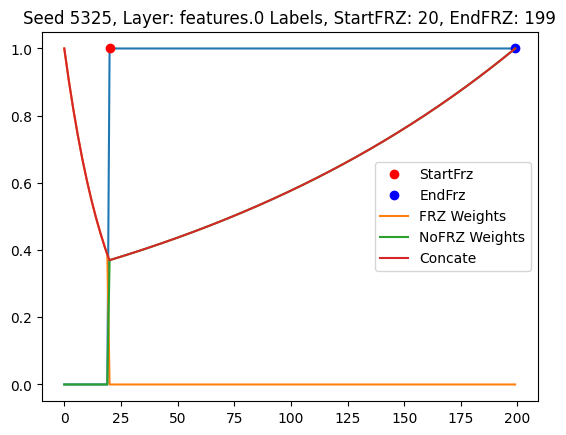

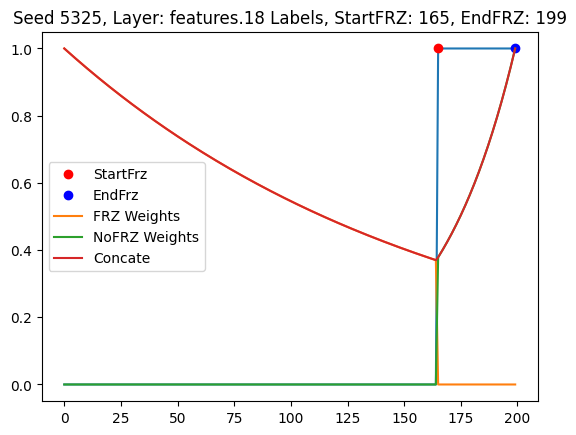

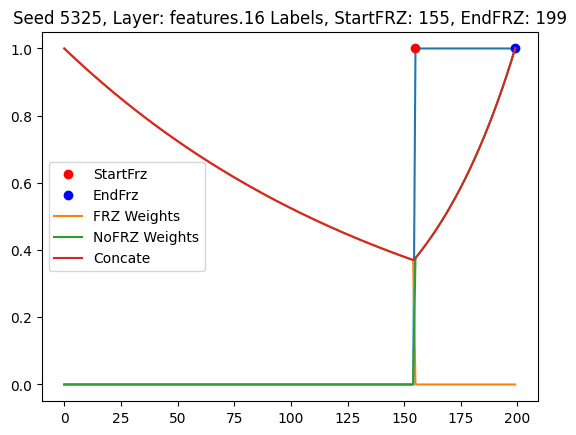

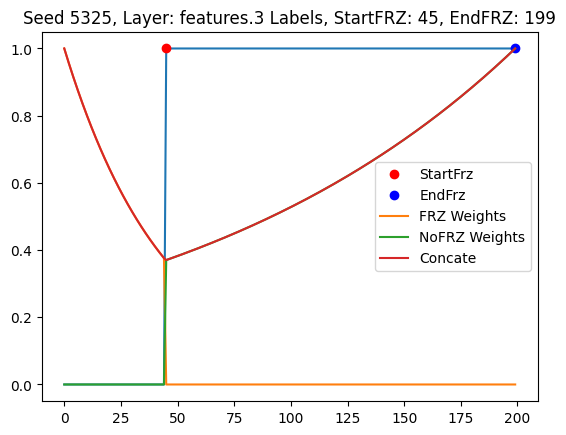

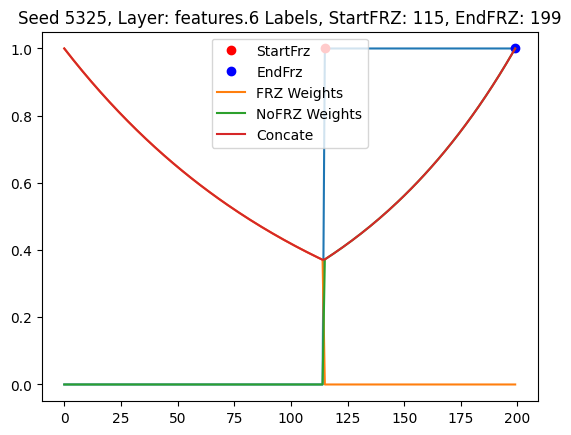

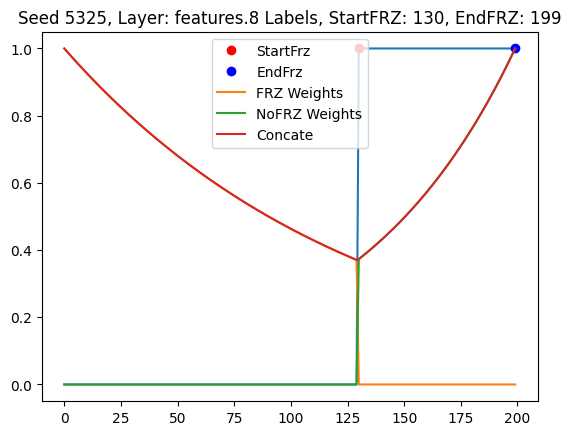

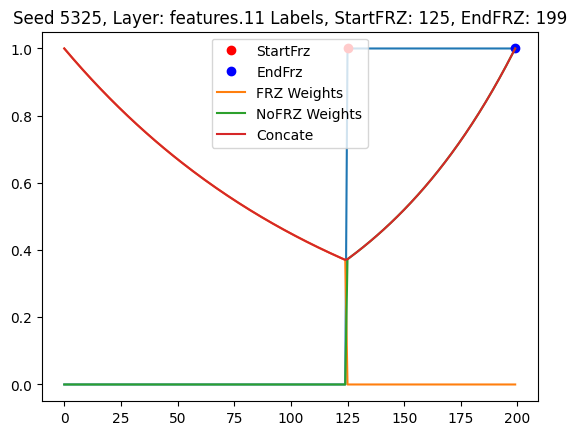

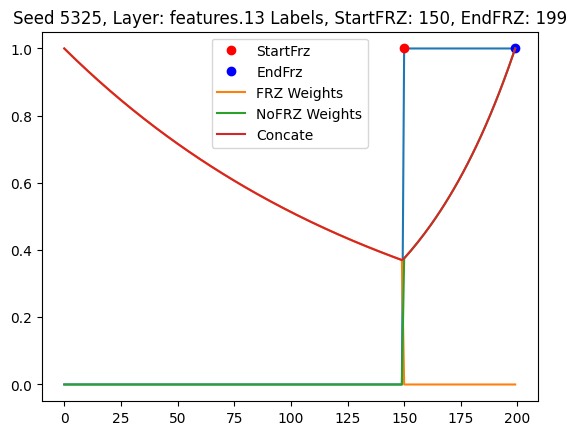

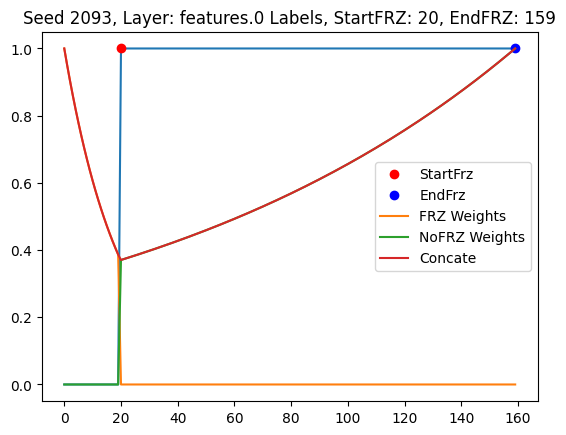

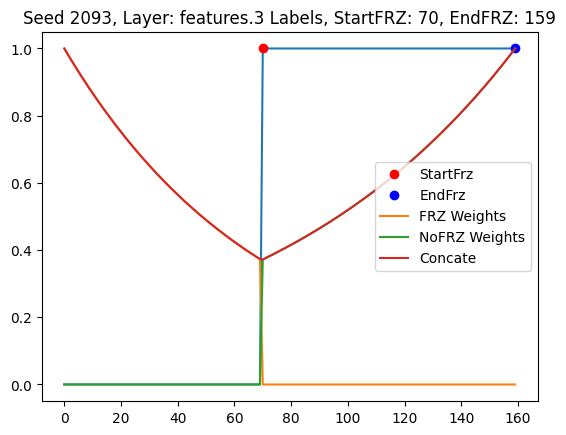

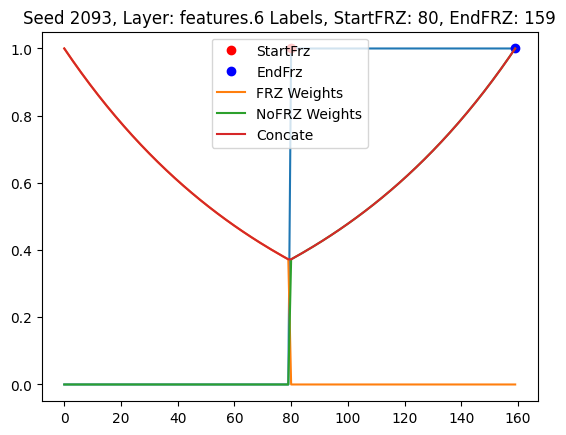

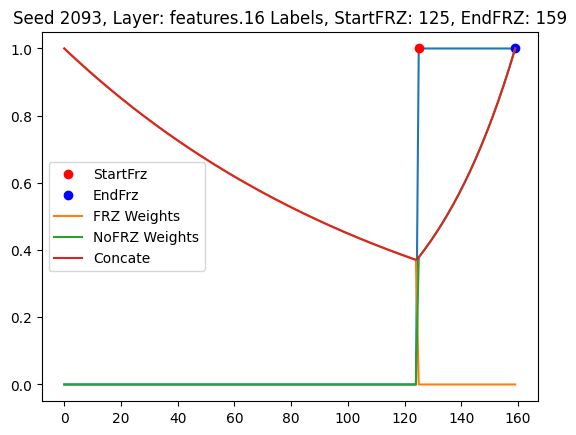

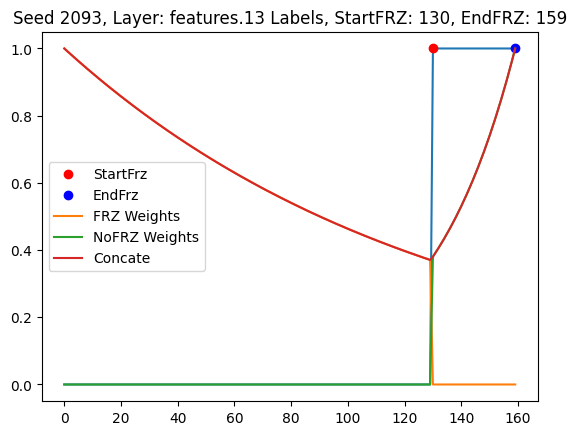

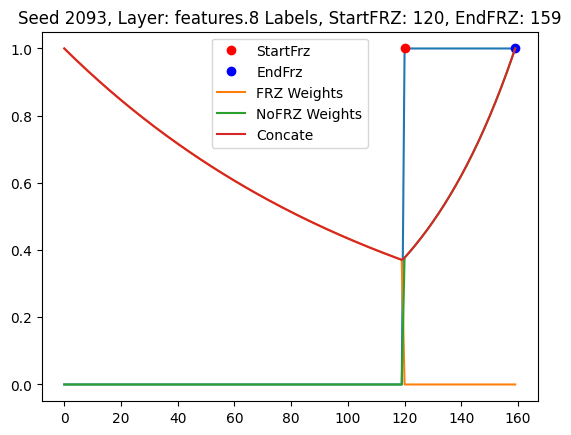

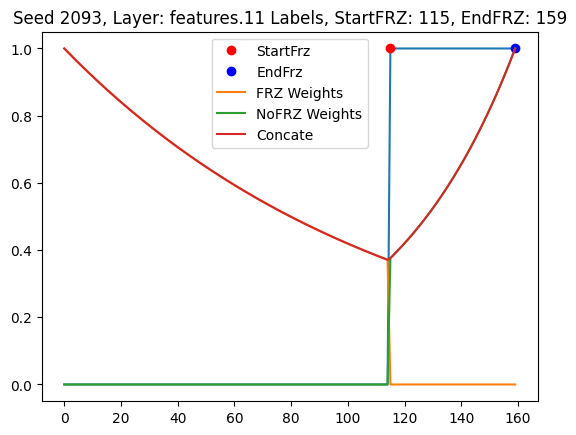

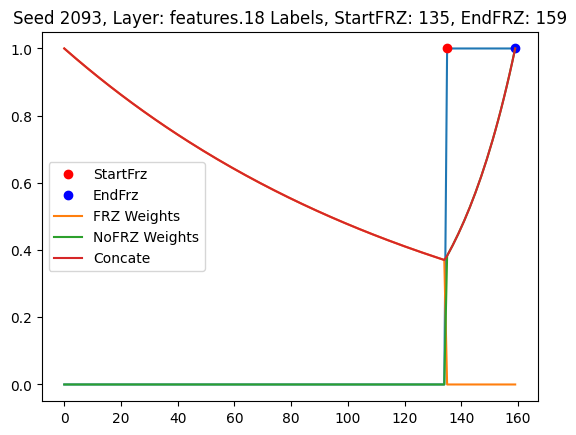

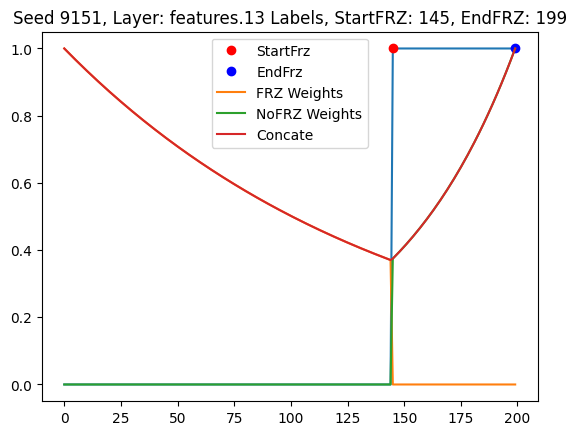

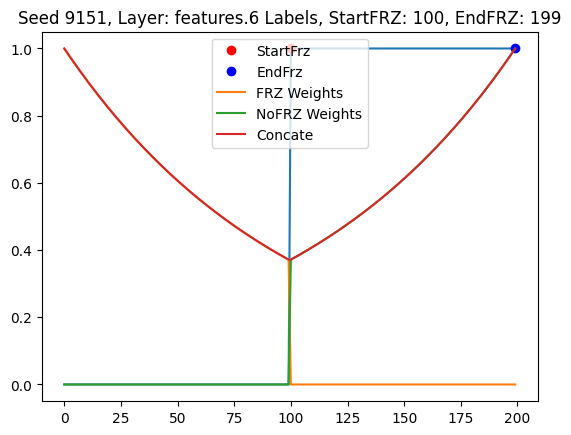

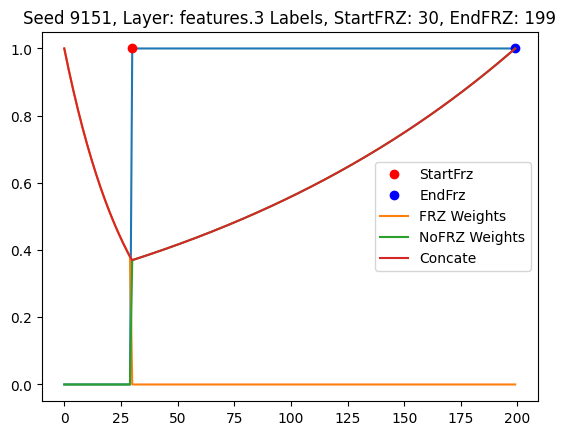

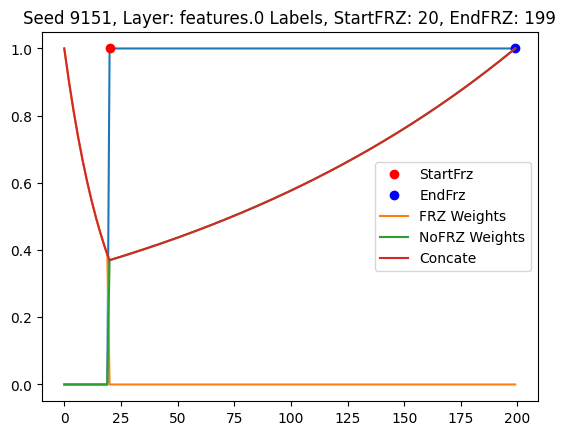

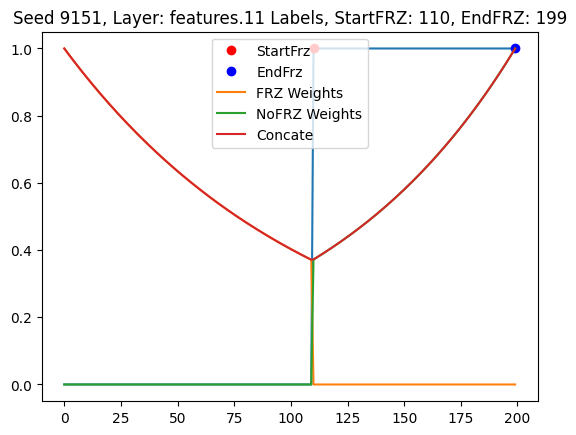

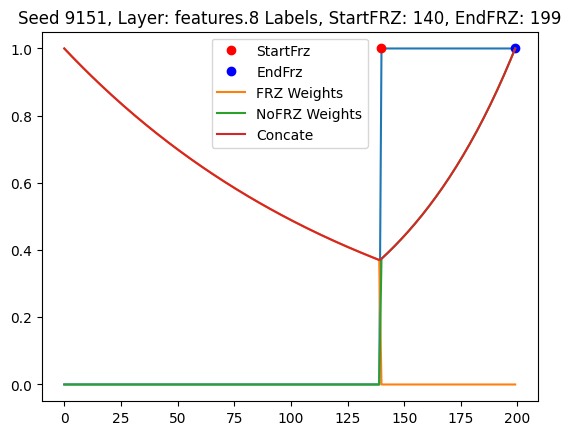

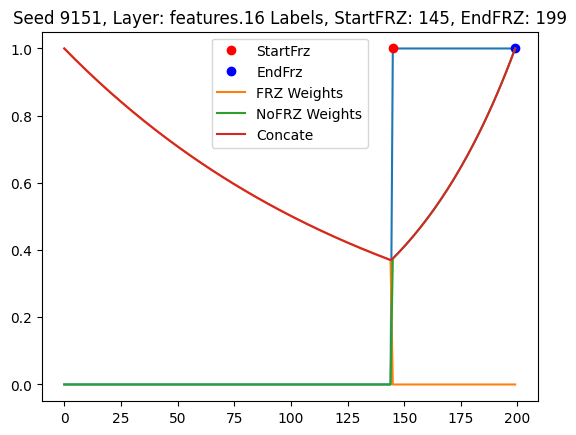

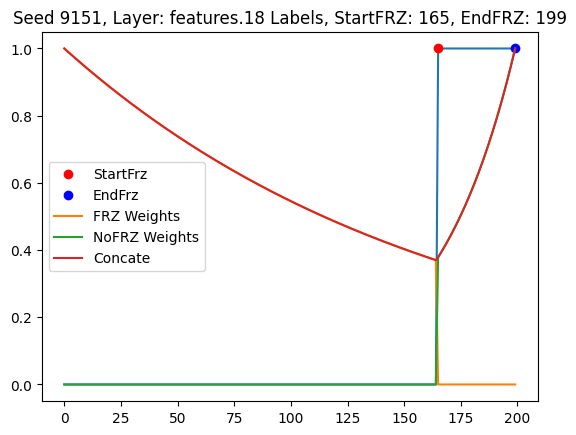

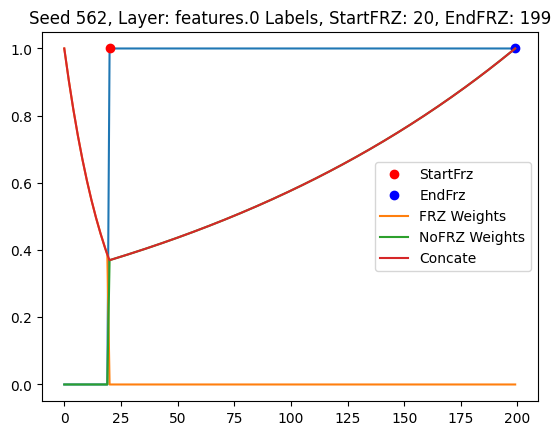

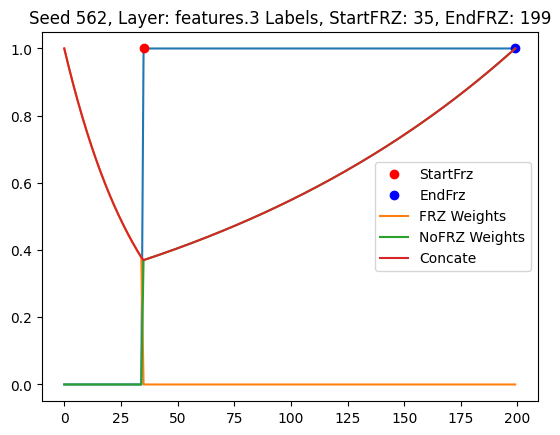

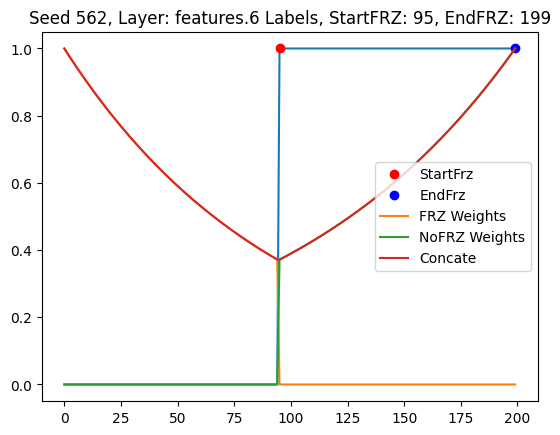

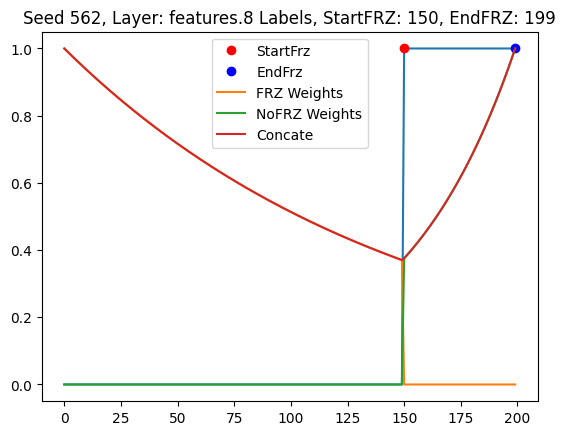

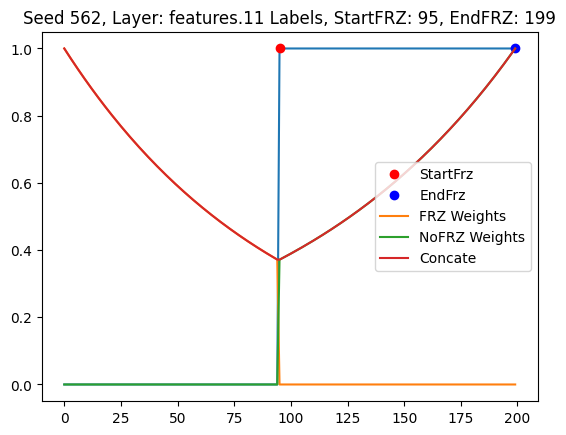

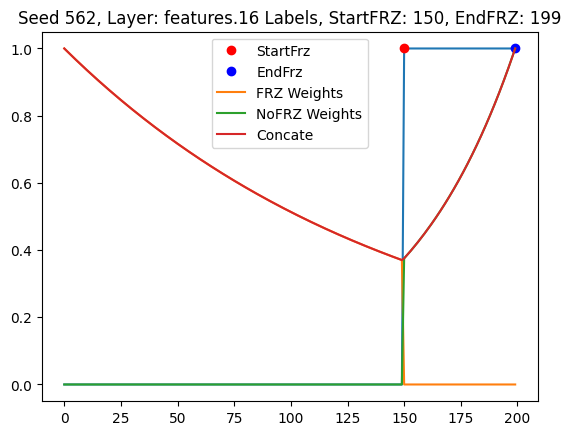

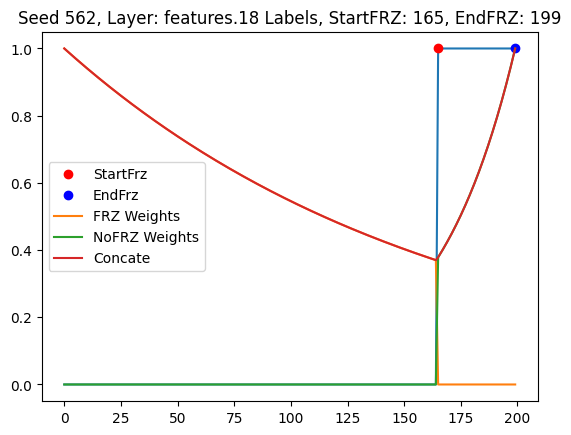

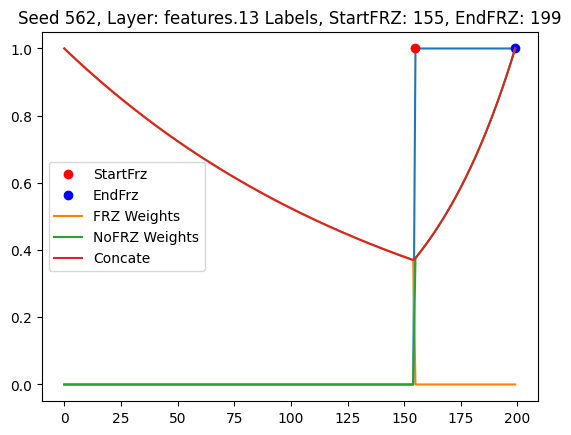

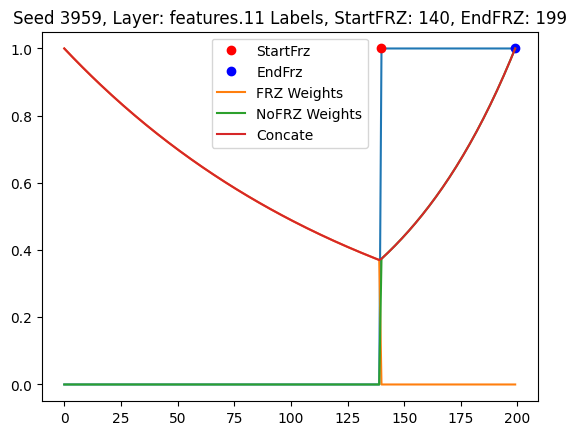

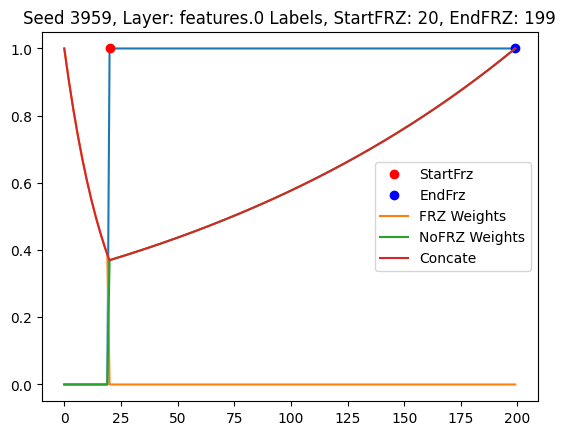

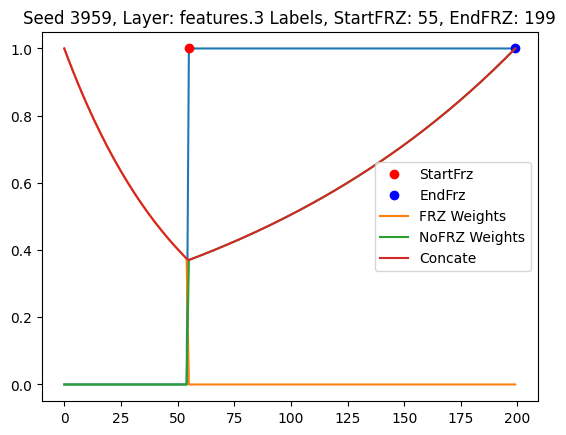

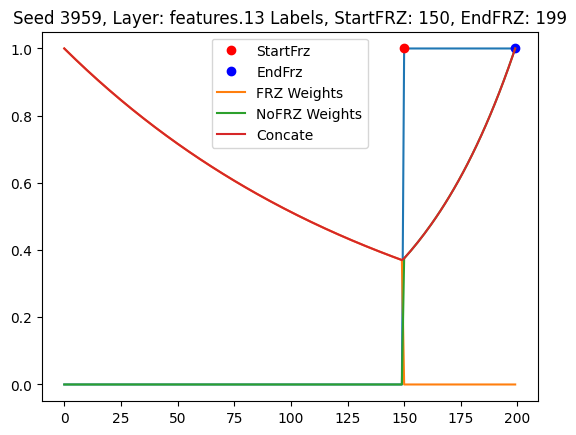

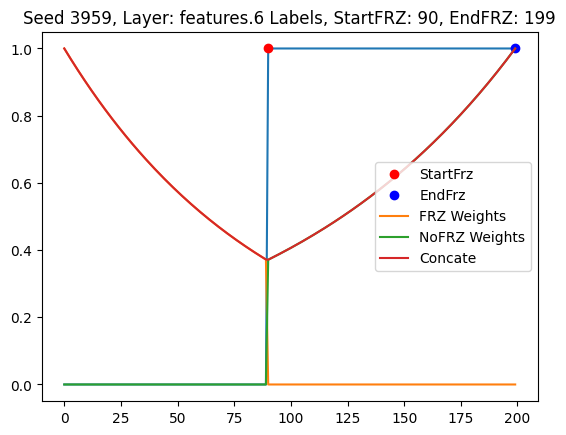

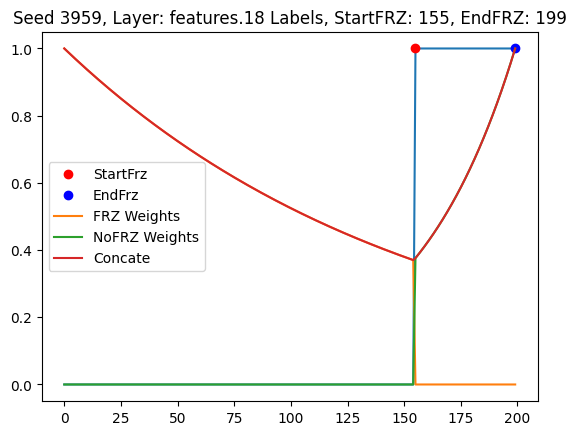

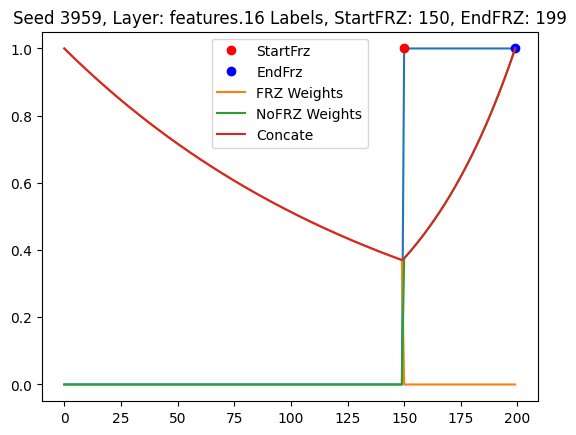

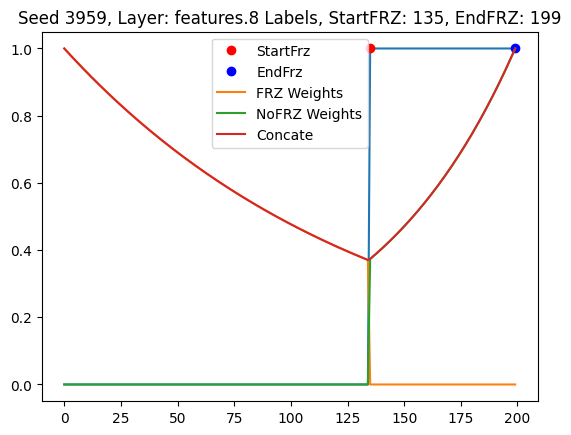

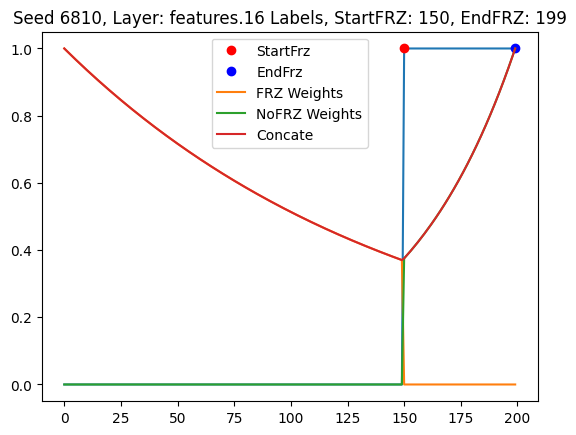

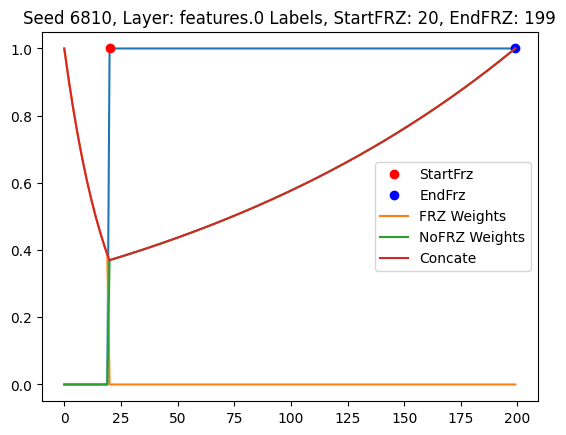

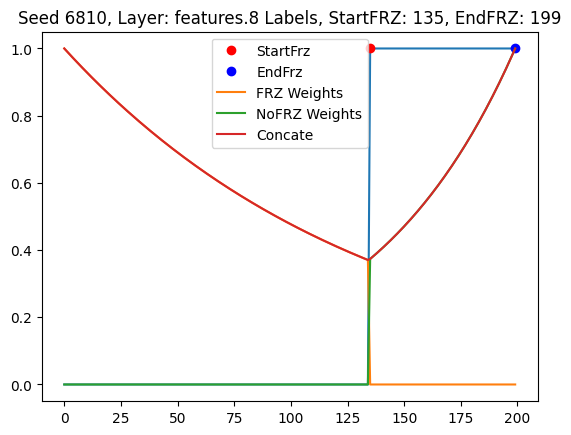

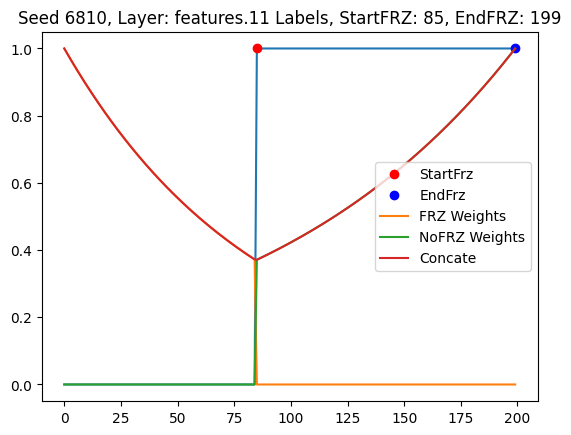

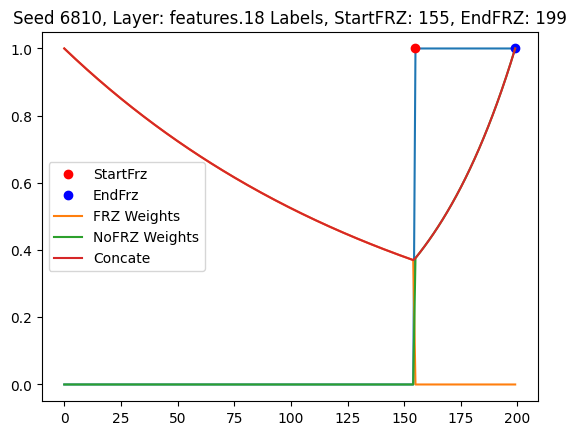

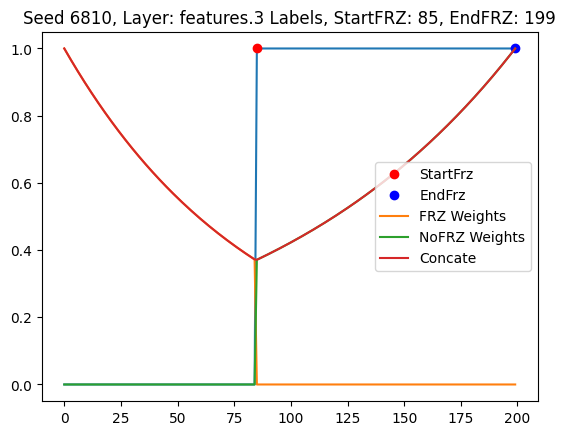

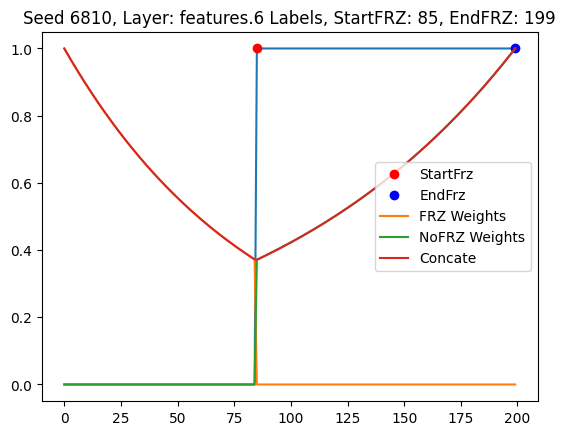

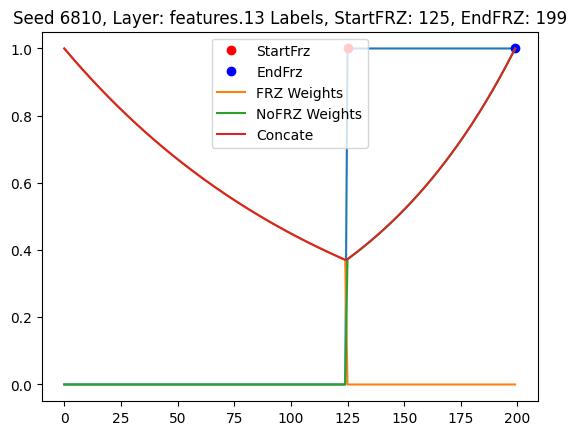

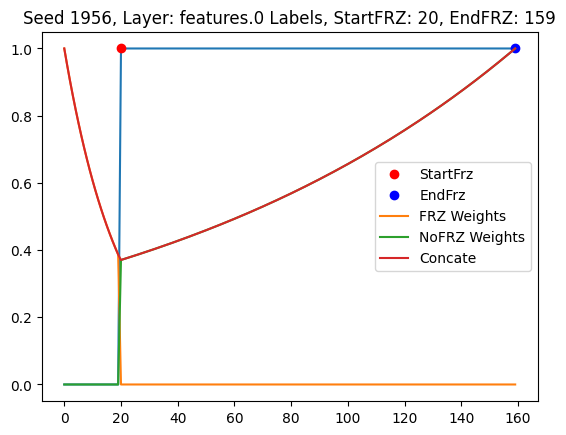

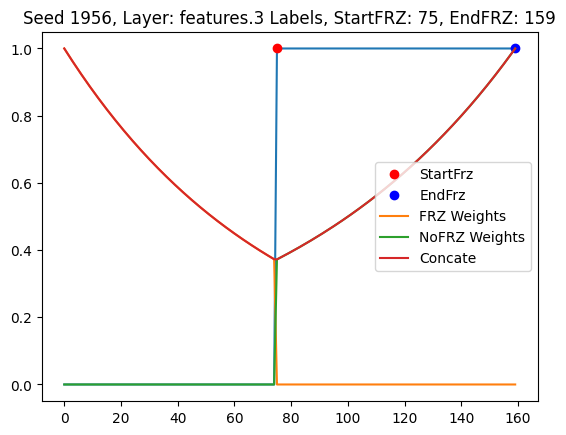

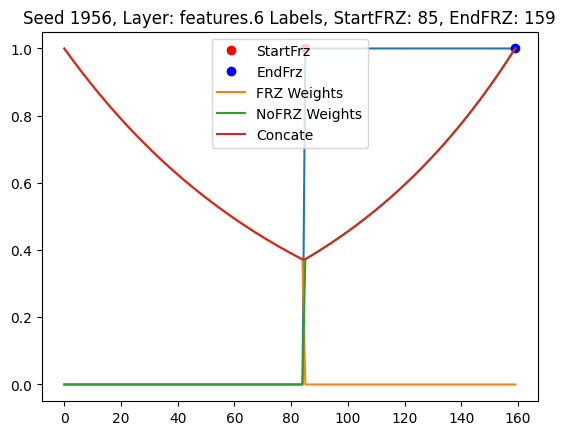

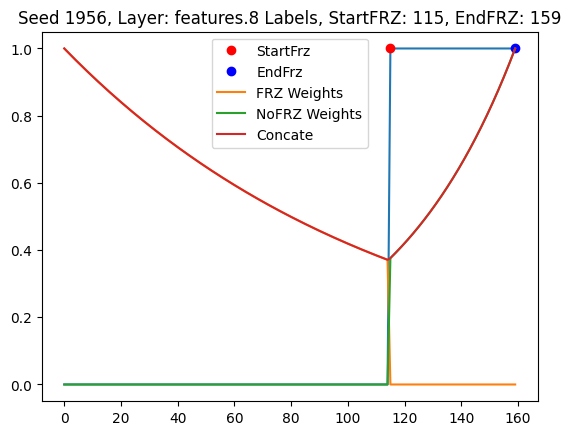

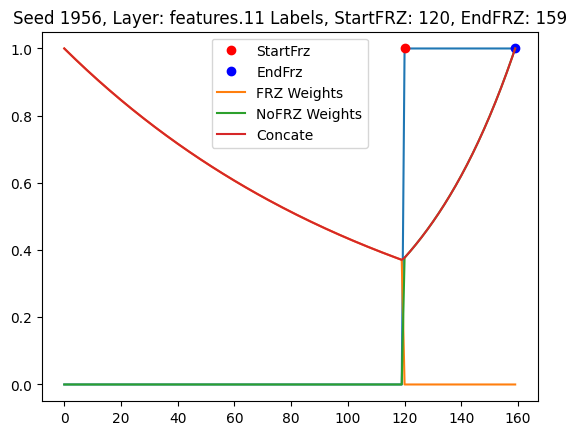

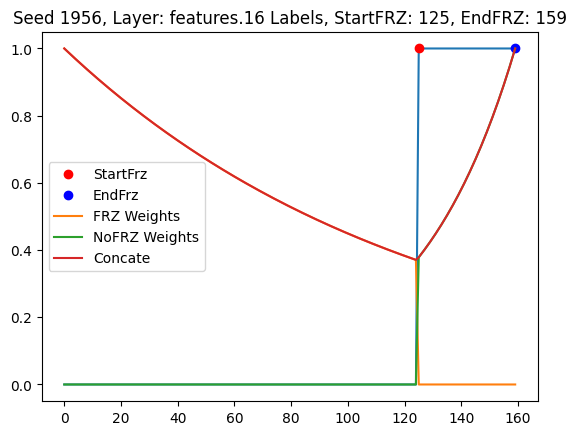

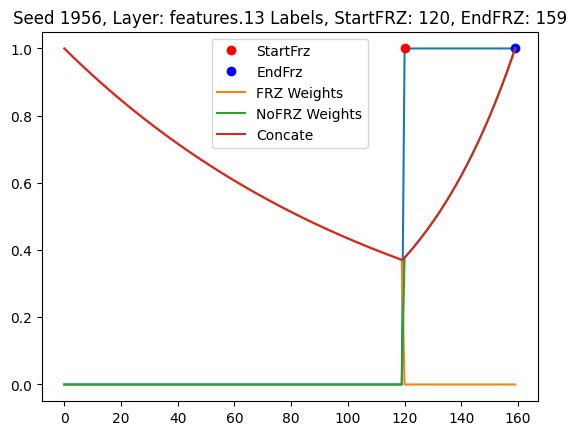

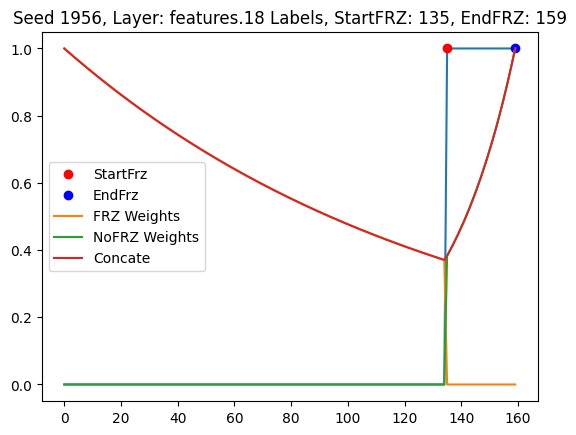

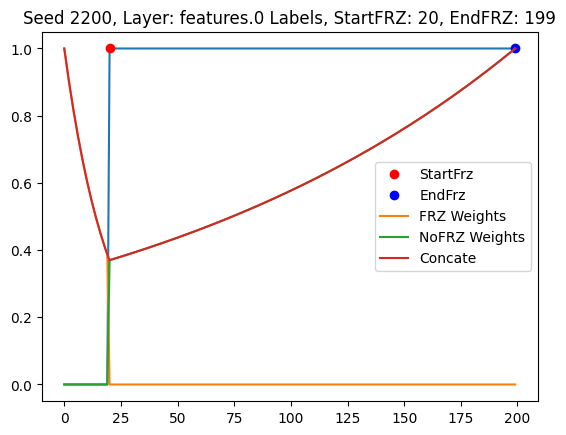

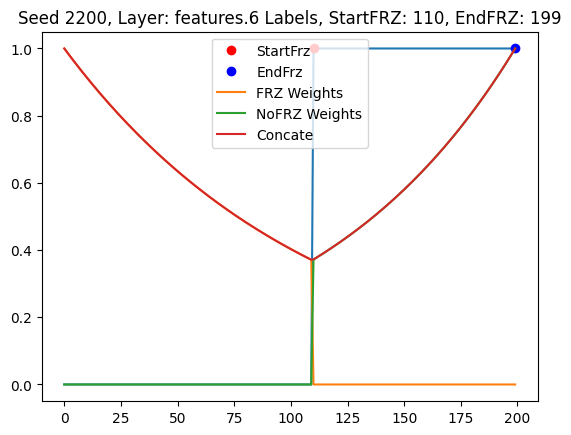

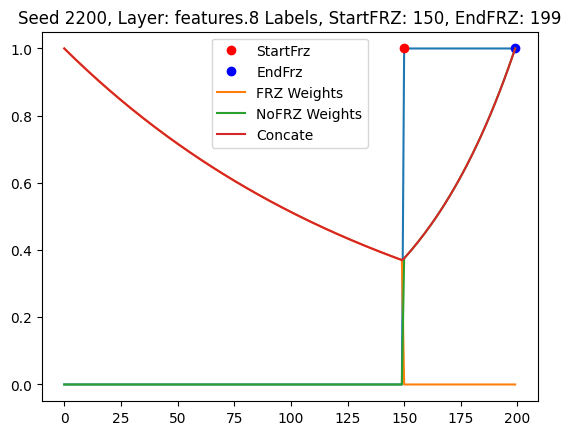

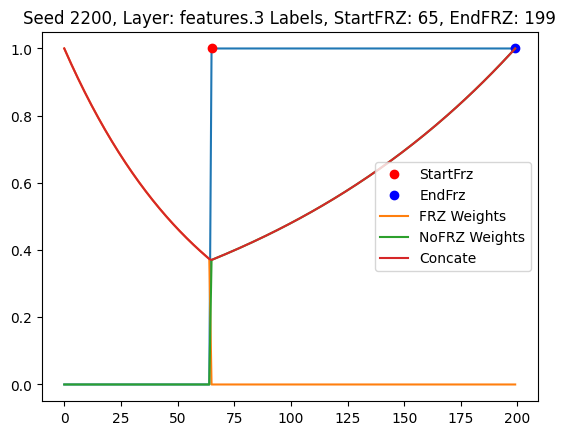

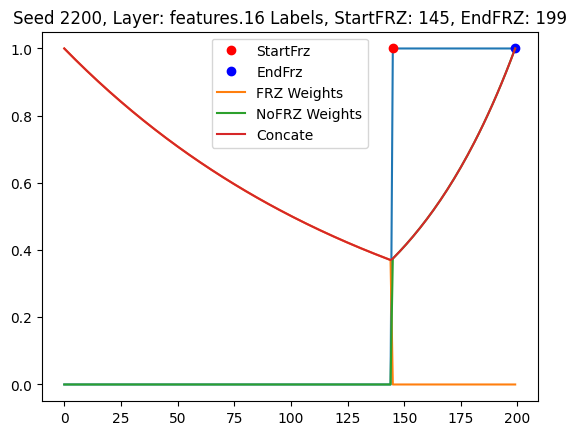

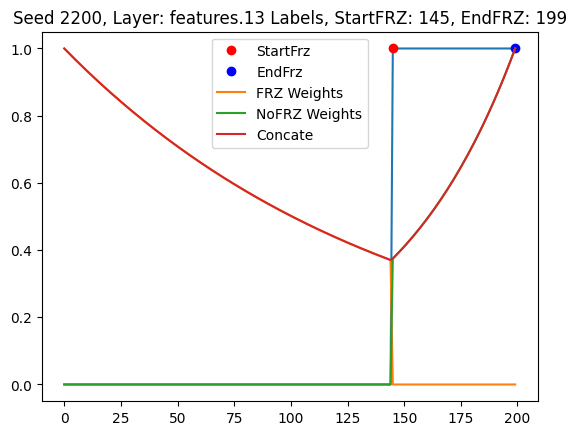

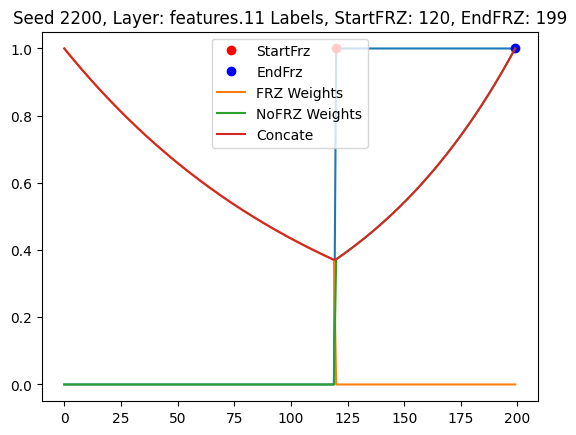

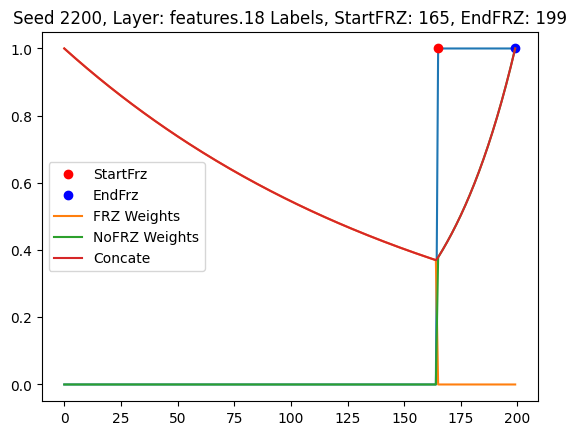

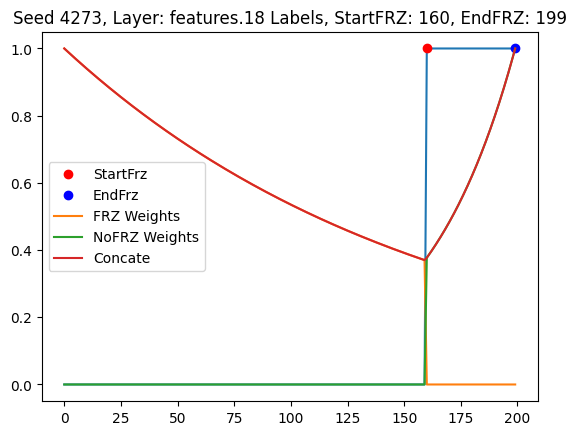

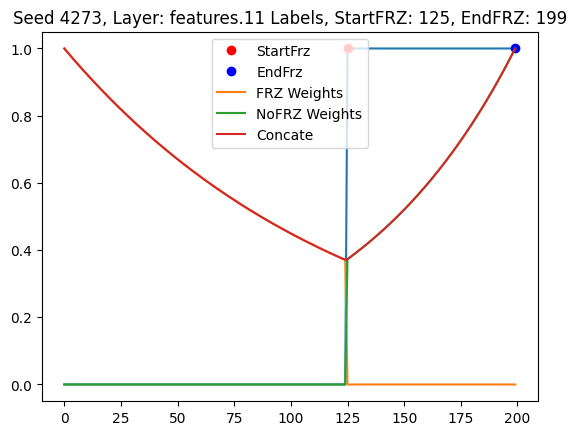

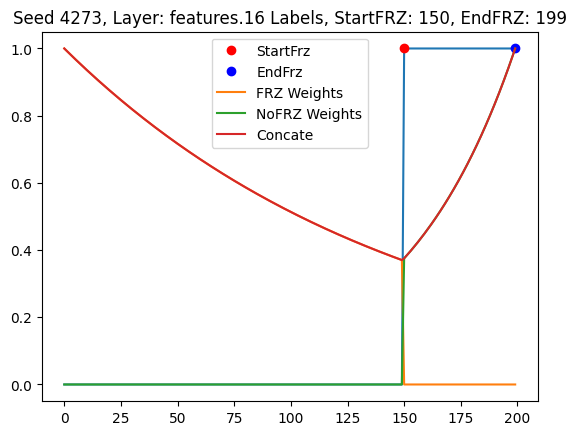

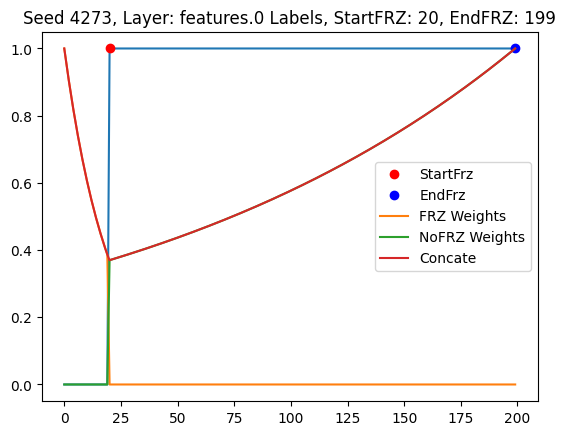

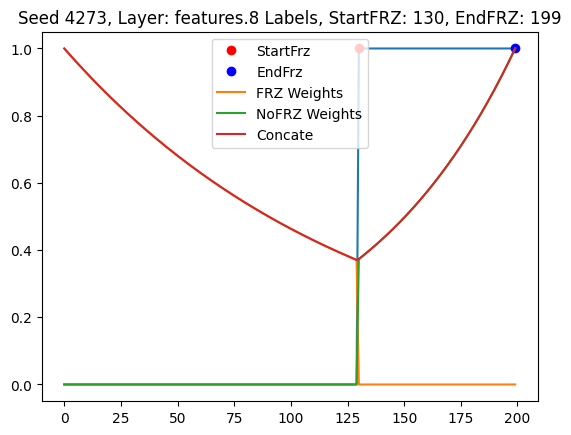

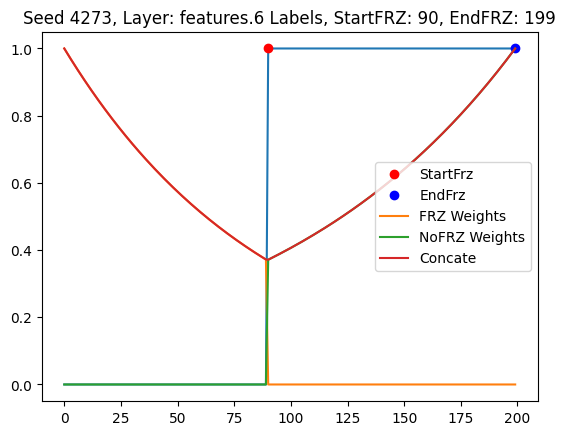

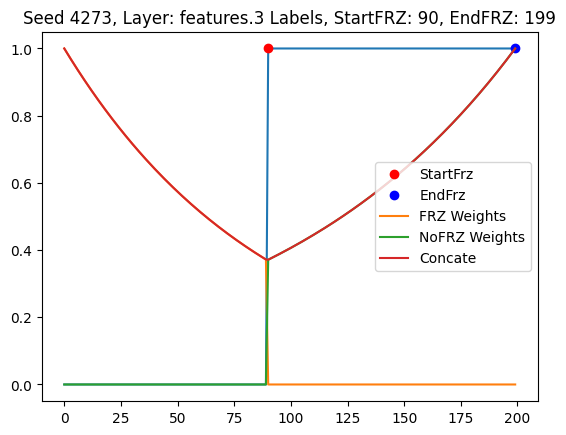

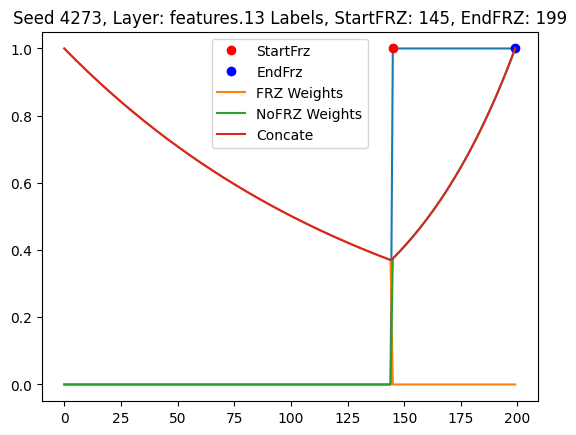

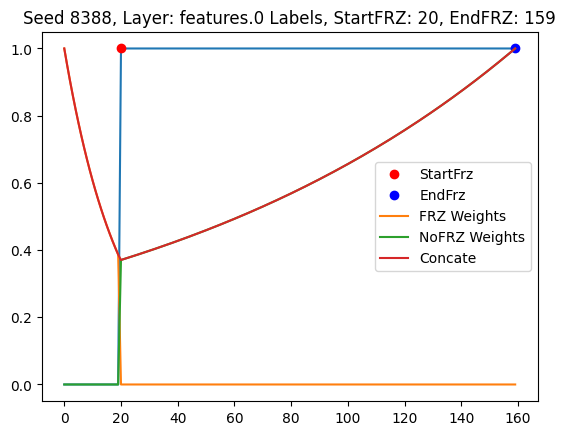

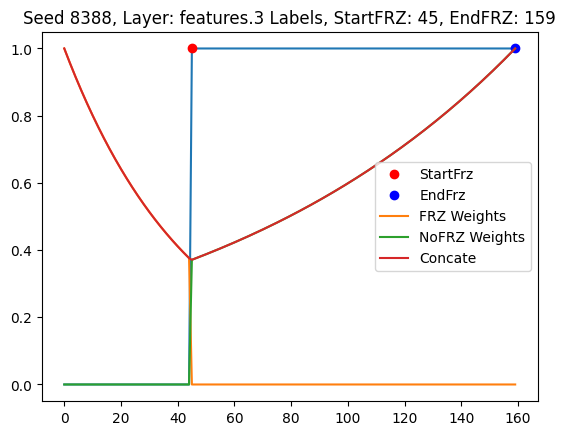

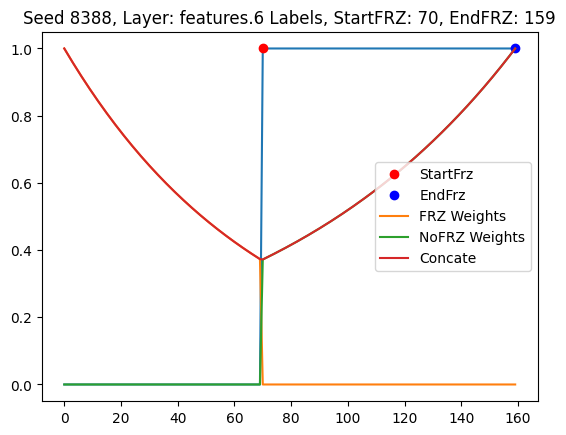

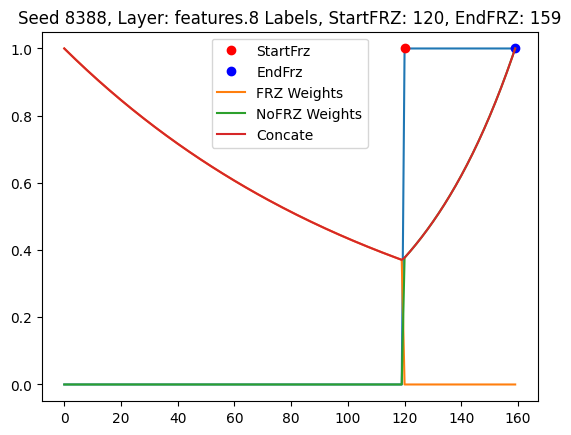

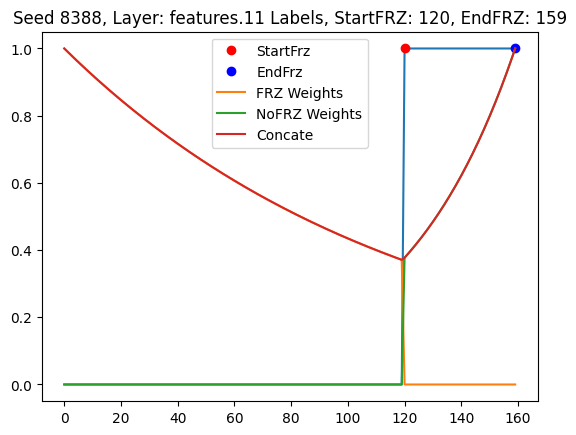

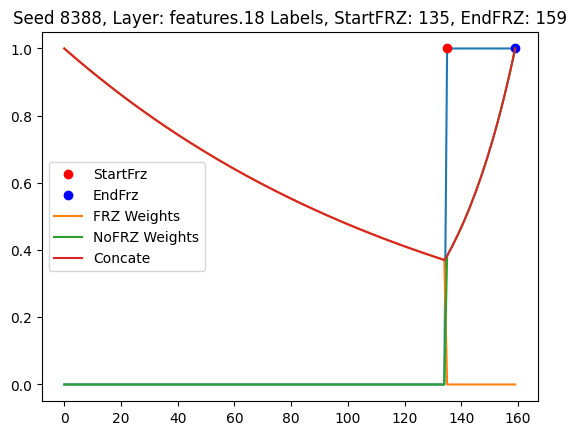

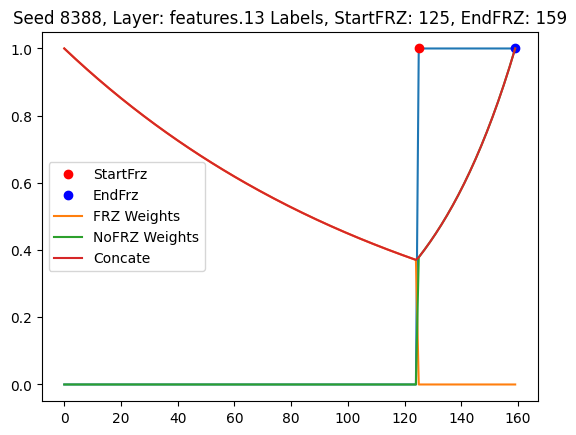

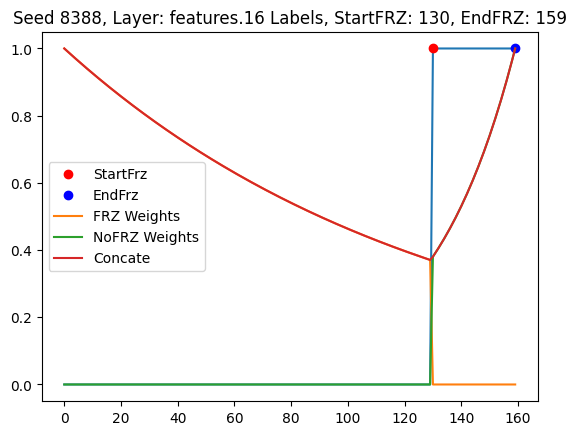

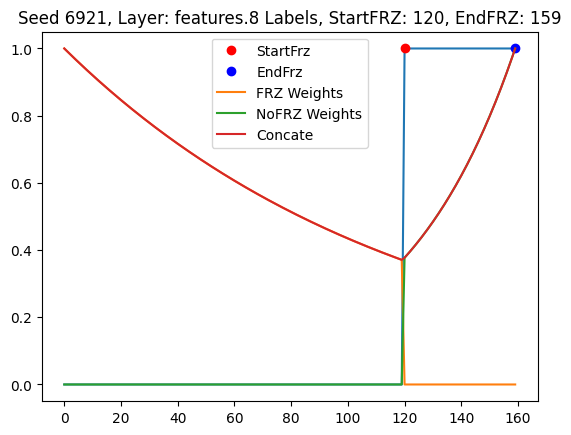

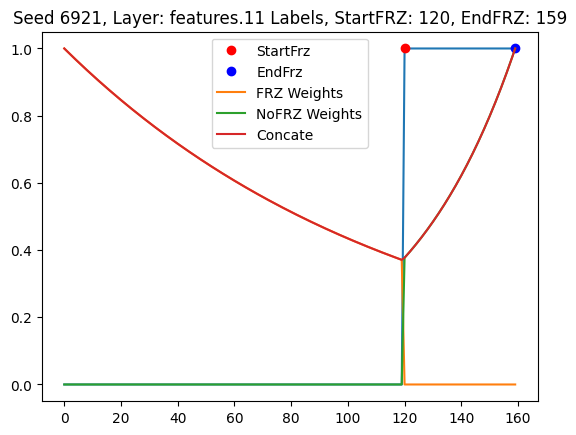

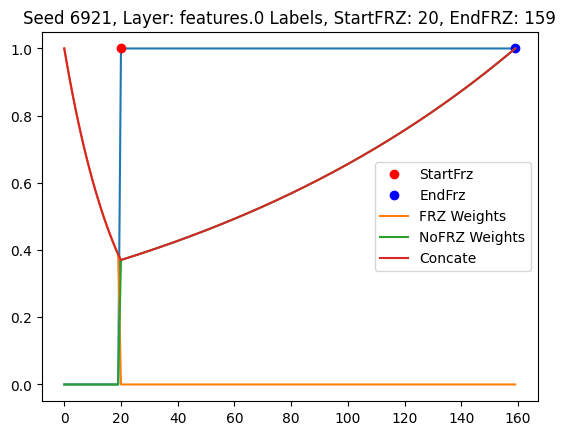

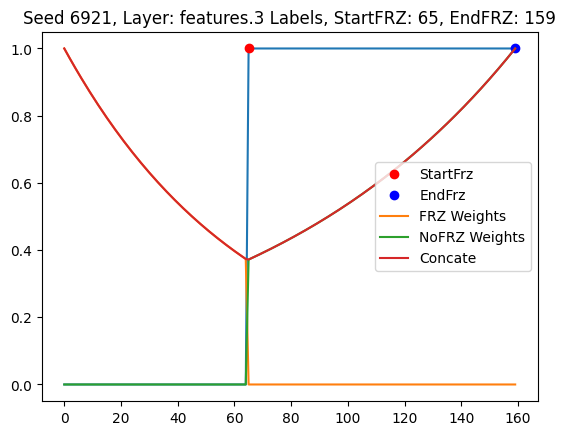

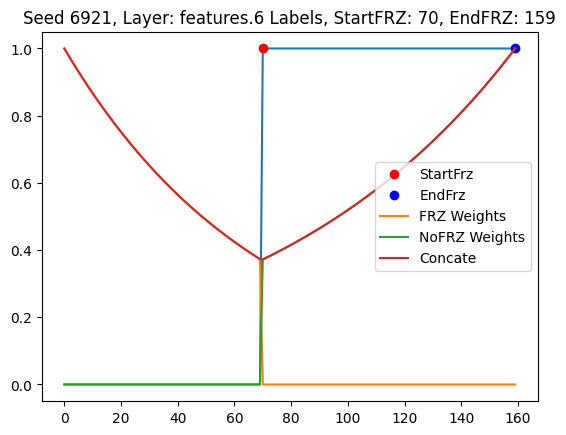

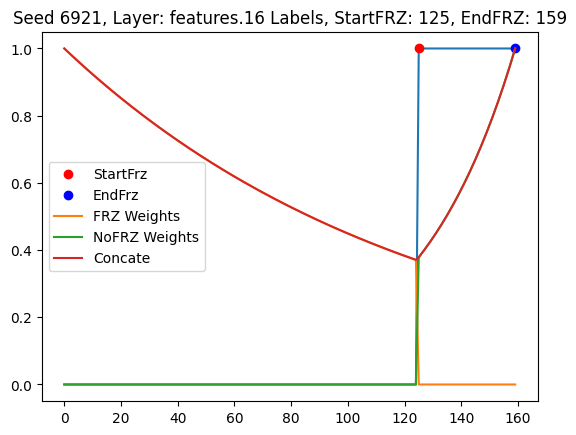

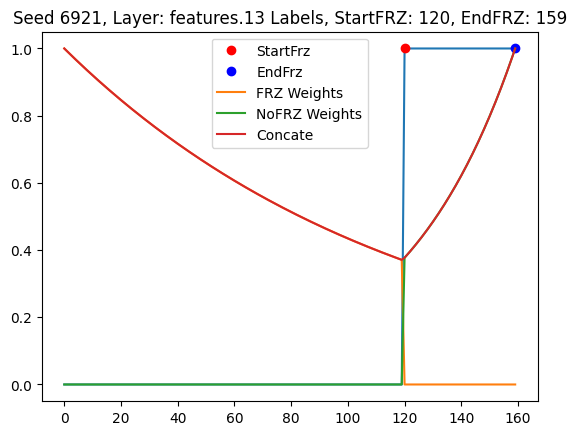

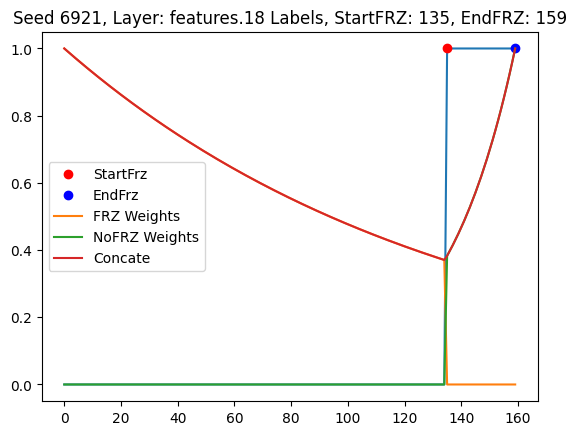

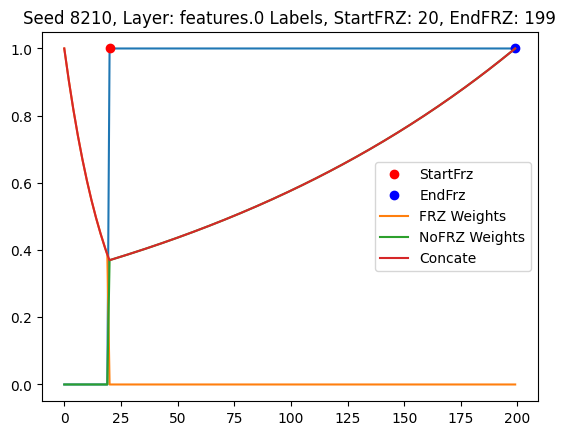

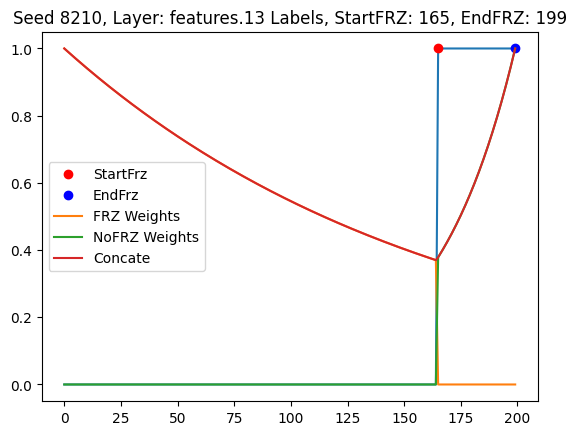

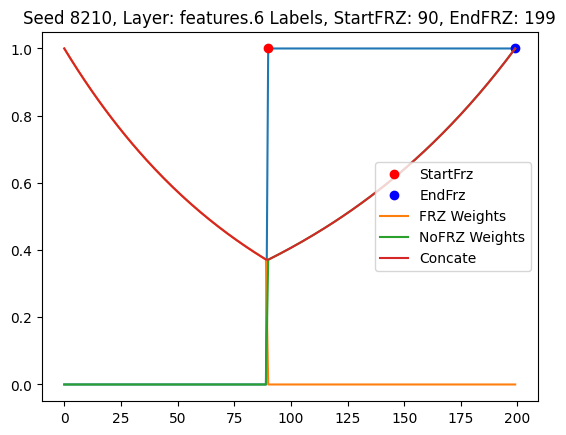

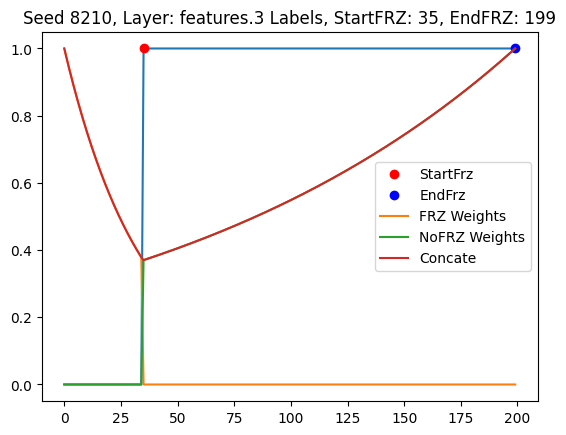

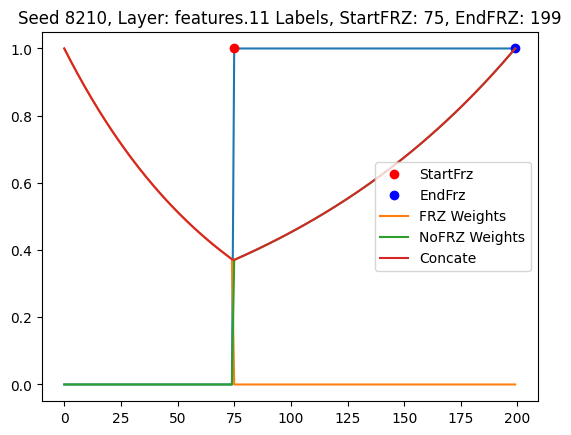

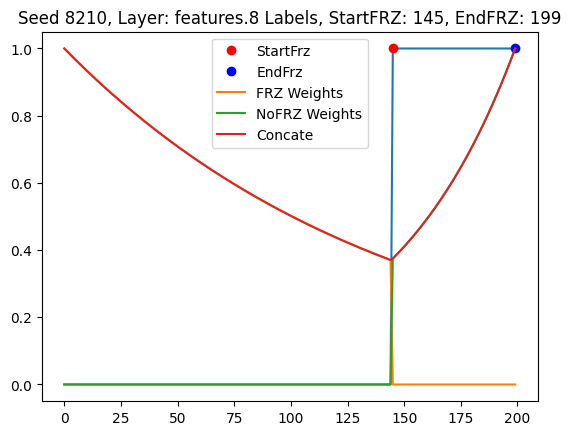

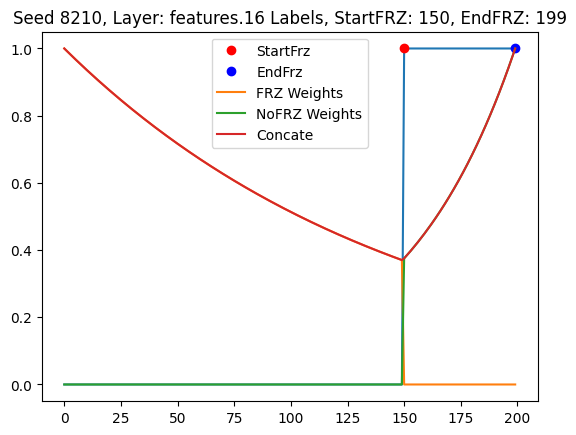

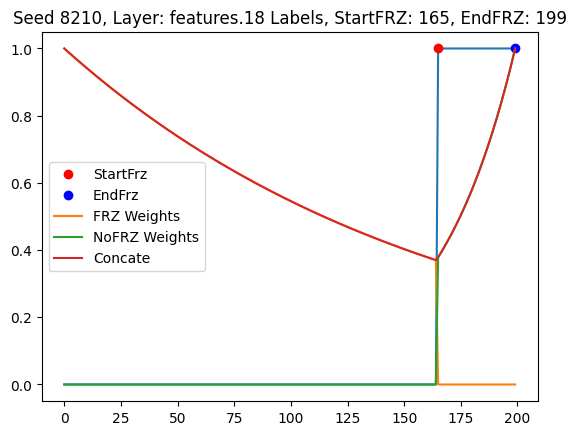

In [44]:
%load_ext autoreload
%autoreload 2
from importance_sampling import get_epoch_list, get_frz_nofrz_samples, get_weights_based_on_distance_from_frz_region
container_for_seed_weights = defaultdict(lambda: defaultdict(dict))
seed_weights_for_sample_importance_for_loss = defaultdict(dict)
for seed in seed_specific_data_copy.keys():
    for conv_layer in seed_specific_data_copy[seed].keys():
        epoch_list = [int(item[0]) for item in seed_specific_data_copy[seed][conv_layer]]
        labels_list = [item[1] for item in seed_specific_data_copy[seed][conv_layer]]
        
        start_frz = labels_list.index(1)
        end_frz = len(labels_list) - 1 - labels_list[::-1].index(1)
        num_epochs = len(labels_list)
        weights_exp_frz, weights_exp_nofrz = get_weights_based_on_distance_from_frz_region(start_frz, end_frz, num_epochs, sample_weight_function="exp", clip_val=0.2)
        
        ## VALIDATION PRINTS ##
        # print(start_frz, end_frz, num_epochs)
        # print(f"Weights at the frz region: NoFrzWeights={weights_exp_nofrz[start_frz]}, FrzWeights={weights_exp_frz[start_frz]}")
        # print(f"NoFrzWeights, weights after the frz region={weights_exp_nofrz[start_frz:]}")
        # print(f"FrzWeights, weights after the frz region={weights_exp_frz[start_frz:]}")
        # print(f"FRZWeights, weights before the frz region={weights_exp_frz[:start_frz]}")
        container_for_seed_weights[seed][conv_layer]["weights_frz"] = weights_exp_frz
        container_for_seed_weights[seed][conv_layer]["weights_nofrz"] = weights_exp_nofrz
        seed_weights_for_sample_importance_for_loss[seed][conv_layer] = torch.concat((torch.tensor(weights_exp_frz[:start_frz]), torch.tensor(weights_exp_nofrz[start_frz:])), dim=0)
        plt.title(f"Seed {seed}, Layer: {conv_layer} Labels, StartFRZ: {start_frz}, EndFRZ: {end_frz}")
        plt.plot(epoch_list, labels_list)
        plt.plot(start_frz, 1, 'ro', label='StartFrz')
        plt.plot(end_frz, 1, 'bo', label='EndFrz')
        plt.plot(epoch_list, container_for_seed_weights[seed][conv_layer]["weights_frz"], label="FRZ Weights")
        plt.plot(epoch_list, container_for_seed_weights[seed][conv_layer]["weights_nofrz"], label="NoFRZ Weights")
        plt.plot(epoch_list, seed_weights_for_sample_importance_for_loss[seed][conv_layer], label="Concate")
        plt.legend()
        plt.show()

In [33]:
# If prediction is frozen, mapping for weights is
# [seed][conv_layer]["weights_frz"][epoch_num]
# If prediction is non-frozen, mapping for weights is
# [seed][conv_layer]["weights_nofrz"][epoch_num]
import torch
import torch.nn.functional as F
logits = torch.tensor([[-3.0, 3.0], [3.0, -3.0], [-1.0, 1.0], [1.0, -1.0]])
print(f"Shape of Logits: {logits.shape}")
labels = torch.tensor([0, 0, 1, 1])
print(f"Shape of Labels: {labels.shape}")
per_sample_loss = F.cross_entropy(logits, labels, reduction='none')
print(f"Per sample loss: {per_sample_loss}")

Shape of Logits: torch.Size([4, 2])
Shape of Labels: torch.Size([4])
Per sample loss: tensor([6.0025e+00, 2.4757e-03, 1.2693e-01, 2.1269e+00])


In [45]:
import pickle
importance_sampling_type = "exp"
with open(f"{root_dir}/sample_importance_weights_{importance_sampling_type}_{frz_predictor_type}.pkl", "wb") as f:
    pickle.dump(seed_weights_for_sample_importance_for_loss, f)